In [1]:
# Importando base de dado
import pandas as pd

# Abrindo base de dado
df = pd.read_excel(r"C:\\Users\\Usuário\\OneDrive\\Desktop\\Faculdade Uninter\\Atividade Extensionista\\tabela_animais.xlsx")
df.head(3) # visualizar 5 linhas

,id,especie,nome,genero,porte,raca,cor,idade,castrado
0,1,cachorro,Zeus,macho,Grande,Sharpei,Preto,8,sim
1,2,cachorro,July,femea,Grande,Mestiça Pitbull,Caramelo,6,sim
2,3,cachorro,Barbicha,macho,Médio,Estopinha,Preto/Branco,5,sim


Tratamento dos dados

In [2]:
# Preencher dados faltantes
df['cor'] = df['cor'].fillna('Preto')

In [3]:
# Tratando as colunas
colunas_texto = ["porte", "raca", "cor", "genero", "especie"]

for col in colunas_texto:
    df[col] = df[col].str.strip().str.capitalize().str.title()

Consumo por porte

In [4]:
consumo_por_porte = {
    "Pequeno": 0.15,
    "Médio": 0.30,
    "Grande": 0.50,
    "Médio/Grande": (0.30 + 0.50) / 2
}

df["consumo_diario_kg"] = df["porte"].map(consumo_por_porte)
df.head(3)

,id,especie,nome,genero,porte,raca,cor,idade,castrado,consumo_diario_kg
0,1,Cachorro,Zeus,Macho,Grande,Sharpei,Preto,8,sim,0.5
1,2,Cachorro,July,Femea,Grande,Mestiça Pitbull,Caramelo,6,sim,0.5
2,3,Cachorro,Barbicha,Macho,Médio,Estopinha,Preto/Branco,5,sim,0.3


Consumo total diario

In [5]:
consumo_total_diario = df["consumo_diario_kg"].sum()
print(f'{consumo_total_diario:.3}')

13.6


Consumo Estatístico

In [6]:
# Criando agrupamento por porte
estoque = df.groupby('porte')['consumo_diario_kg'].agg(['sum', 'count', 'mean'])

# Calculando o gasto total da matilha por dia
gasto_diario_total = estoque['sum'].sum()

# Planejamento para 30 dias com 15% de margem
dias_planejados = 30
estoque_necessario = (gasto_diario_total * dias_planejados) * 1.15

print('          Tabela consumo por porte')
print(estoque)
print()
print(f"Gasto Diário: {gasto_diario_total:.2f} kg")
print(f"Estoque para {dias_planejados} dias: {estoque_necessario:.2f} kg")



          Tabela consumo por porte
              sum  count  mean
porte                         
Grande        6.0     12  0.50
Médio         4.8     16  0.30
Médio/Grande  0.4      1  0.40
Pequeno       2.4     16  0.15

Gasto Diário: 13.60 kg
Estoque para 30 dias: 469.20 kg


Estoque período 7 dias

In [7]:
# Importando biblioteca
import numpy as np

# Dados
media_diaria = 13.6  # O consumo total por dia
lead_time = 7 # tempo de espera
z = 2 # Nível de confiança alto
desvio_padrao = df["consumo_diario_kg"].std() # Desvio padrão da base

# Cálculo Estatístico
estoque_seguranca = z * desvio_padrao * np.sqrt(lead_time)
ponto_ressuprimento = (media_diaria * lead_time) + estoque_seguranca
print(f"Estoque Mínimo para 7 dias: {ponto_ressuprimento:.2f} kg") # Garantia de 7 dias
print(f"Sendo {estoque_seguranca:.2f} kg apenas para cobrir variações (Segurança)")



Estoque Mínimo para 7 dias: 95.94 kg
Sendo 0.74 kg apenas para cobrir variações (Segurança)


Duração por dia

In [8]:
estoque_atual = 120 # Duração por dia

dias_duracao = estoque_atual / consumo_total_diario
print(f'duração por dia: {dias_duracao:.2f} dias aproximadamente')

duração por dia: 8.82 dias aproximadamente


Gráfico: Controle do estoque

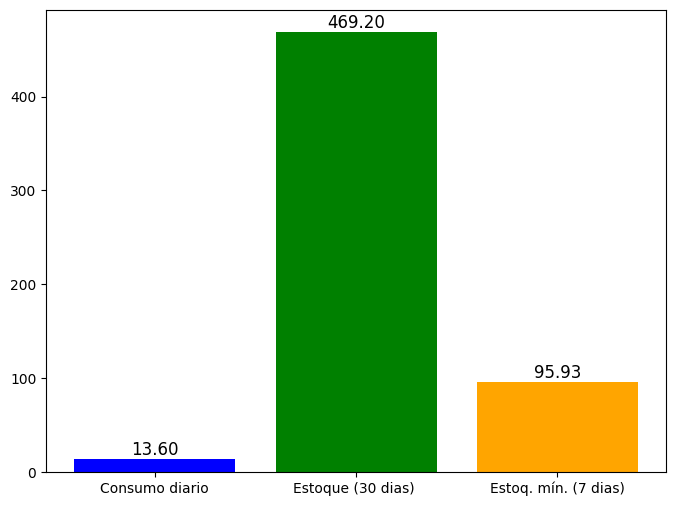

In [9]:
# Importando biblioteca
import matplotlib.pyplot as plt

# Dados 
consumo_total_diario = 13.60
estoque_necessario = 469.20
ponto_ressuprimento = 95.93

dados = [consumo_total_diario, estoque_necessario, ponto_ressuprimento]
nomes = ['Consumo diario', 'Estoque (30 dias) ', 'Estoq. mín. (7 dias)']

plt.figure(figsize=(8, 6))

# Plotando as barras
barras = plt.bar(nomes, dados, color=['blue', 'green', 'orange'])

# Loop automático para colocar os números com 2 casas decimais
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        f'{altura:.2f}', # formato para 2 casas decimais
        ha='center',
        va='bottom',
        fontsize=12
    )

plt.show()


Gráfico: Gestão de estoque

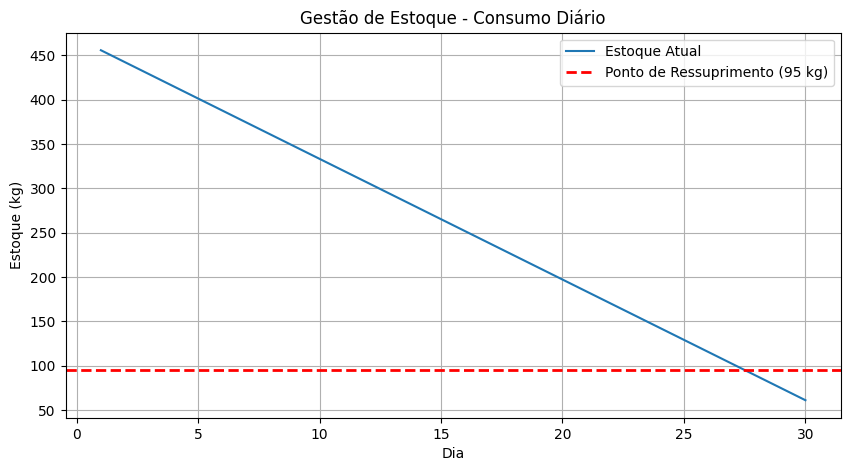

In [11]:
# Importando bibliotecas
import matplotlib.pyplot as plt
import numpy as np

# Dados do estoque diário
dias = np.arange(1, 31)
# Estoque em kg
estoque = 469.2 - (dias * 13.6) 

# Parâmetros
ponto_ressuprimento = 95

# Criar gráfico
plt.figure(figsize=(10, 5))
plt.plot(dias, estoque, label='Estoque Atual', linestyle='-')

# Adicionar a linha de limite (Ponto de Ressuprimento)
plt.axhline(y=ponto_ressuprimento, color='red', linestyle='--', linewidth=2, label='Ponto de Ressuprimento (95 kg)')

# Customização
plt.title('Gestão de Estoque - Consumo Diário')
plt.xlabel('Dia')
plt.ylabel('Estoque (kg)')
plt.legend()
plt.grid(True)

# Exibir
plt.show()
